Average Headline Length: 80.02 characters


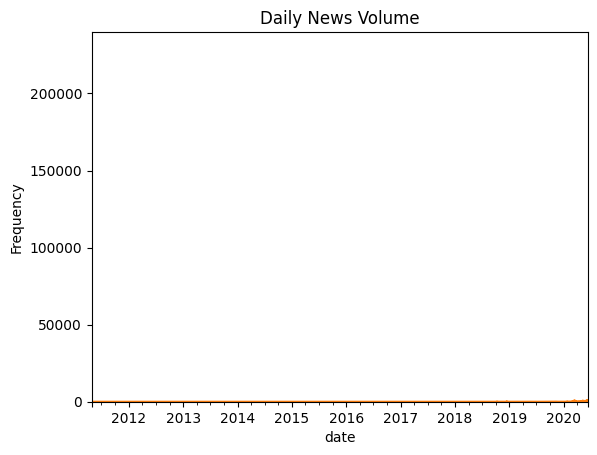

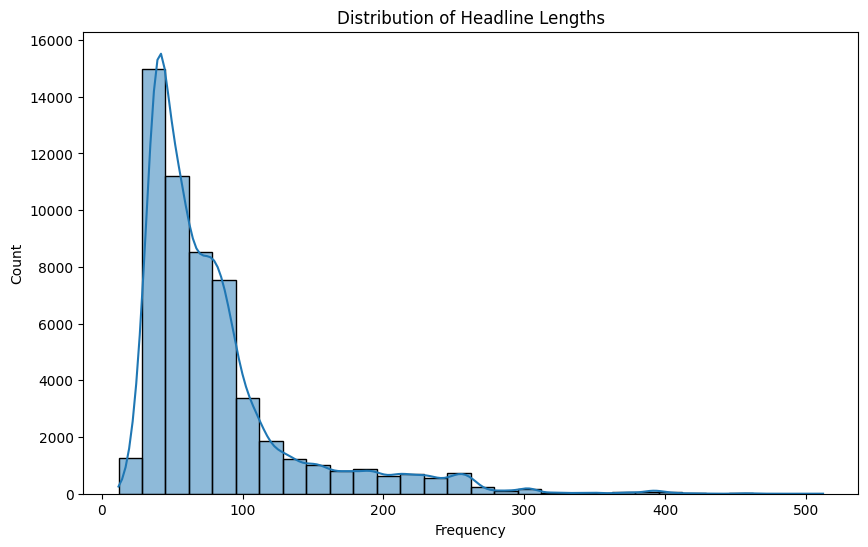

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Load the Financial News Dataset
df_news = pd.read_csv('../data/raw/newsData/raw_analyst_ratings.csv')

#Load the stock data (for Task 2 progress)
df_stocks = pd.read_csv('../data/raw/yfinance_data/Data/AAPL.csv')

#Descriptive statistics: Headline Length
df_news['headline_len'] = df_news['headline'].apply(len)
df_news['headline_len'].plot(kind='hist', bins=50, title='Headline Length Distribution')

df_news['publisher'].value_counts().head(10).plot(kind='bar', title='Top 10 Publishers')
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)
df_news = df_news.dropna(subset=['date'])
df_news.set_index('date').resample('D').size().plot(title='Daily News Volume')
print(f"Average Headline Length: {df_news['headline_len'].mean():.2f} characters")

#3. Simple Visualization for Task 1
plt.figure(figsize=(10,6))
sns.histplot(df_news['headline_len'], bins=30, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Frequency')
plt.show()

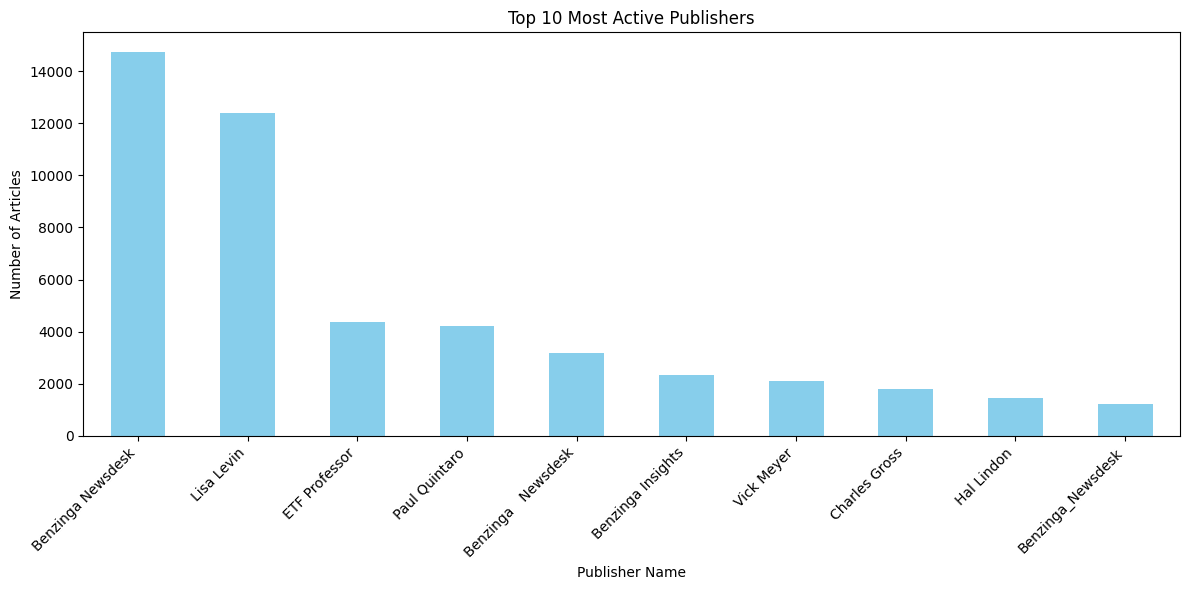

In [23]:
#count articles per publisher and plot top 10
top_10_publishers = df_news['publisher'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_10_publishers.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

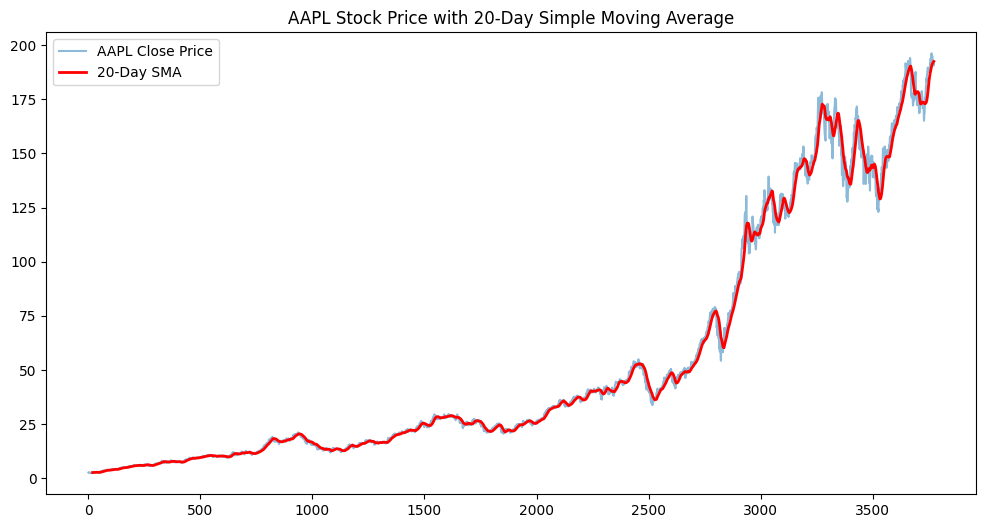

In [24]:
#Task 2: Calculate a 20-day Simple Moving Average (SMA) for AAPL
df_stocks['SMA_20'] = df_stocks['Close'].rolling(window=20).mean()

#Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_stocks['Close'], label='AAPL Close Price', alpha=0.5)
plt.plot(df_stocks['SMA_20'], label='20-Day SMA', color='red', linewidth=2)
plt.title('AAPL Stock Price with 20-Day Simple Moving Average')
plt.legend()
plt.show()

In [25]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply to headlines
df_news['sentiment'] = df_news['headline'].apply(get_sentiment)

# Group by date to get daily average sentiment
daily_sentiment = df_news.groupby('date')['sentiment'].mean().reset_index()
print(daily_sentiment.head())

                       date  sentiment
0 2011-04-28 01:01:48+00:00   0.000000
1 2011-04-28 17:49:29+00:00   0.136364
2 2011-04-28 19:00:36+00:00   0.000000
3 2011-04-29 17:47:06+00:00  -0.166667
4 2011-04-29 20:11:05+00:00   0.500000


In [26]:
# Simple RSI implementation
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df_stocks['RSI'] = calculate_rsi(df_stocks['Close'])

In [27]:
import talib
import numpy as np 

In [28]:
import pandas as pd
import talib
import os

# 1. Define paths and tickers
# Adjust 'base_path' if your folder structure is different
base_path = "../data/raw/yfinance_data/Data/"
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stock_data = {}

# 2. Load data and apply TA-Lib indicators
for ticker in tickers:
    file_path = os.path.join(base_path, f"{ticker}.csv")
    
    if os.path.exists(file_path):
        # Load the CSV
        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
        df = df.sort_index()
        
        # Calculate RSI (TA-Lib)
        df['RSI'] = talib.RSI(df['Close'].values, timeperiod=14)
        
        # Calculate MACD (TA-Lib)
        macd, macdsignal, macdhist = talib.MACD(df['Close'].values, 
                                                fastperiod=12, 
                                                slowperiod=26, 
                                                signalperiod=9)
        df['MACD'] = macd
        df['MACD_Signal'] = macdsignal
        
        stock_data[ticker] = df
        print(f"✅ Loaded and processed TA-Lib for {ticker}")
    else:
        print(f"❌ Could not find file: {file_path}")

# Verify the first few rows of AAPL
if 'AAPL' in stock_data:
    print("\nPreview of AAPL with TA-Lib Indicators:")
    print(stock_data['AAPL'][['Close', 'RSI', 'MACD']].tail())

✅ Loaded and processed TA-Lib for AAPL
✅ Loaded and processed TA-Lib for AMZN
✅ Loaded and processed TA-Lib for GOOG
✅ Loaded and processed TA-Lib for META
✅ Loaded and processed TA-Lib for NVDA

Preview of AAPL with TA-Lib Indicators:
                 Close        RSI      MACD
Date                                       
2023-12-22  191.788757  54.672784  2.633141
2023-12-26  191.243912  53.090049  2.304751
2023-12-27  191.342972  53.354446  2.029104
2023-12-28  191.768951  54.540999  1.823998
2023-12-29  190.728775  51.121347  1.559539


In [29]:
from textblob import TextBlob

# 1. Calculate sentiment for each headline
df_news['sentiment'] = df_news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 2. Resample to Daily Mean Sentiment
# Ensure 'date' is a datetime object first
df_news['date'] = pd.to_datetime(df_news['date'], utc=True)
daily_sentiment = df_news.set_index('date').resample('D')['sentiment'].mean().fillna(0)

print("✅ Daily sentiment trend calculated.")

✅ Daily sentiment trend calculated.


In [30]:
def categorize_financial_theme(text):
    text = str(text).lower()
    # Define themes and their keywords
    themes = {
        'Financial Performance': ['earnings', 'revenue', 'profit', 'loss', 'eps', 'guidance', 'quarter'],
        'Macroeconomics': ['fed', 'interest', 'inflation', 'rate', 'hike', 'economy', 'gdp'],
        'Corporate Actions': ['dividend', 'split', 'payout', 'buyback', 'ipo'],
        'M&A': ['merger', 'acquisition', 'buyout', 'deal', 'takeover'],
        'Market Sentiment': ['bullish', 'bearish', 'rally', 'crash', 'volatility']
    }
    
    for theme, keywords in themes.items():
        if any(word in text for word in keywords):
            return theme
    return 'General Market News'

# 1. Apply the theme categorization
df_news['theme'] = df_news['headline'].apply(categorize_financial_theme)

# 2. Link this to sentiment to see which themes are most positive/negative
theme_analysis = df_news.groupby('theme')['sentiment'].agg(['mean', 'count']).sort_values(by='count', ascending=False)

print("✅ Financial Theme Analysis Completed:")
print(theme_analysis)

✅ Financial Theme Analysis Completed:
                           mean  count
theme                                 
General Market News    0.042361  40827
Financial Performance  0.006500   8908
Macroeconomics         0.066141   2430
M&A                    0.031914   1772
Corporate Actions      0.049763   1343
Market Sentiment       0.079906    707


In [31]:
# 1. Make sure the 'date' column is ready
df_news['date'] = pd.to_datetime(df_news['date'], utc=True)

# 2. Create the daily sentiment average
# We use .tz_localize(None) here to prevent the 'tz-naive' error from before
daily_sentiment = df_news.set_index('date').resample('D')['sentiment'].mean().fillna(0)
daily_sentiment.index = daily_sentiment.index.tz_localize(None)

print("✅ daily_sentiment is recreated and ready for merging.")

# 3. Now try the merge for AAPL again
# Ensure AAPL index is also timezone-naive
stock_data['AAPL'].index = stock_data['AAPL'].index.tz_localize(None)

merged_df = stock_data['AAPL'].join(daily_sentiment, how='inner')
print(f"✅ Merge successful! Rows in merged data: {len(merged_df)}")

✅ daily_sentiment is recreated and ready for merging.
✅ Merge successful! Rows in merged data: 2296


In [32]:
# 1. Strip timezone from both indices to ensure they match
stock_data['AAPL'].index = stock_data['AAPL'].index.tz_localize(None)
daily_sentiment.index = daily_sentiment.index.tz_localize(None)

# 2. Perform the Join
merged_df = stock_data['AAPL'].join(daily_sentiment, how='inner')

# 3. Calculate Correlation using TA-Lib column names
correlation_matrix = merged_df[['sentiment', 'Close', 'RSI', 'MACD']].corr()

print("Correlation Analysis for AAPL (TA-Lib Version):")
print(correlation_matrix['sentiment'])

Correlation Analysis for AAPL (TA-Lib Version):
sentiment    1.000000
Close       -0.043741
RSI         -0.000733
MACD        -0.009372
Name: sentiment, dtype: float64


In [33]:
for ticker in stock_data:
    # Fix the timezone for each stock dataframe
    stock_data[ticker].index = stock_data[ticker].index.tz_localize(None)

Correlation for AAPL: -0.0437


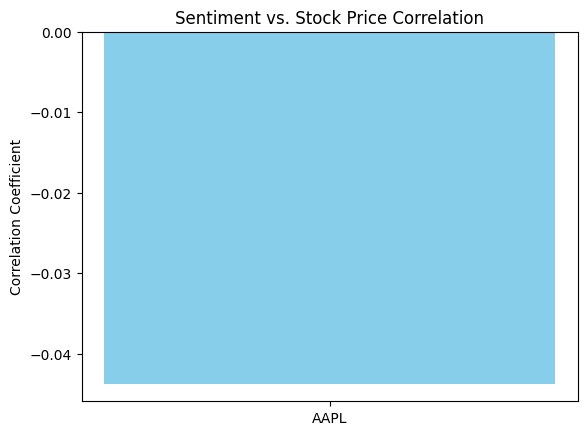

Correlation for AMZN: -0.0324


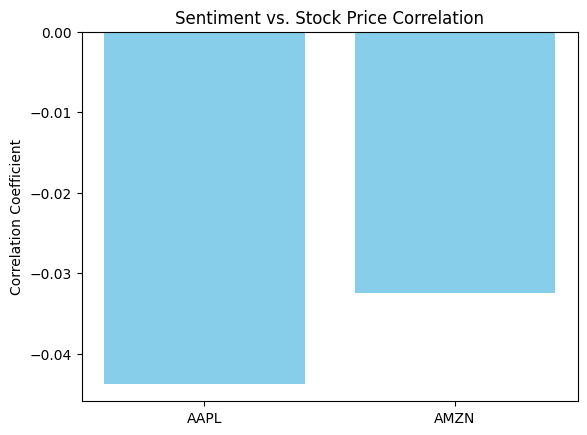

Correlation for GOOG: -0.0480


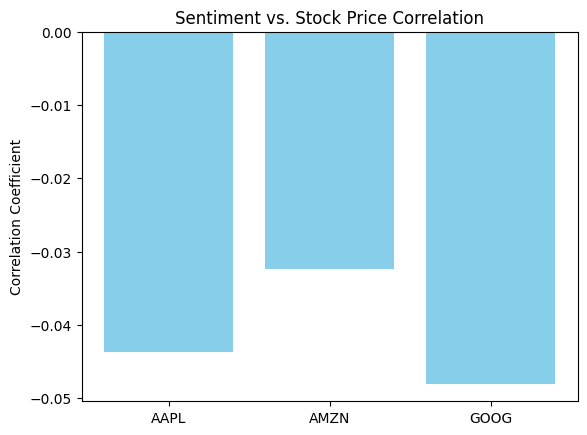

Correlation for META: -0.0289


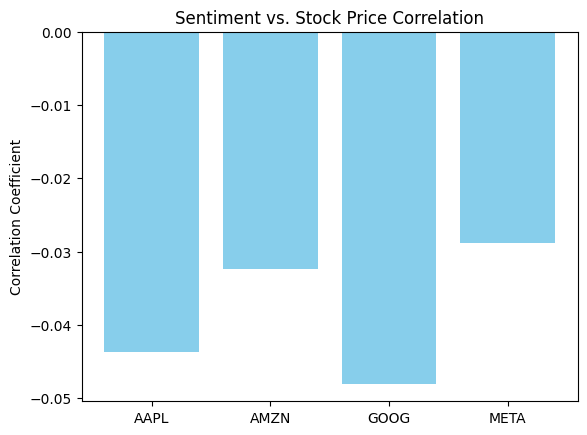

Correlation for NVDA: -0.0272


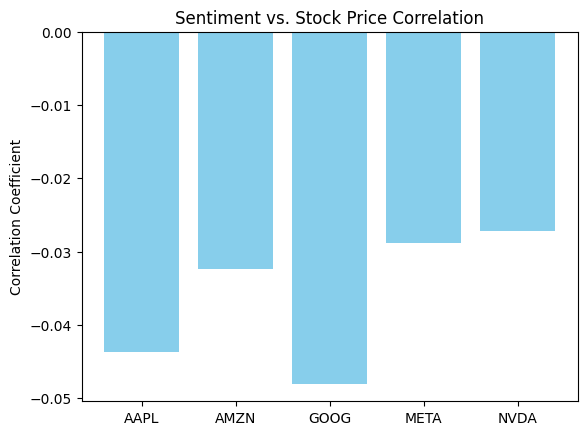

In [34]:
results = {}
for ticker in ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']:
    #1. Ensure timezone is stripped 
    stock_data[ticker].index = stock_data[ticker].index.tz_localize(None)
    #2. Merge 
    temp_merged = stock_data[ticker].join(daily_sentiment, how = 'inner')
    #3. Calculate Correlation
    corr = temp_merged[['sentiment', 'Close']].corr().iloc[0, 1]
    results[ticker] = corr
    print(f"Correlation for {ticker}: {corr:.4f}")

    #vizualize the comparision
    import matplotlib.pyplot as plt
    plt.bar(results.keys(), results.values(), color = 'skyblue')
    plt.title('Sentiment vs. Stock Price Correlation')
    plt.ylabel('Correlation Coefficient')
    plt.show()